<a href="https://colab.research.google.com/github/uiwoos2/26-2-DIP-202202515/blob/main/HW/HW01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

실습코드00:

ITK-SNAP으로 day15를 day0에 registration을 진행한 결과파일을 불러와서 같은 단면을 day0, day15에 대해 display하여 비교하기.


In [4]:
!pip install nibabel
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

In [10]:
ct_base = nib.load('volume-covid19-A-0700_day000.nii').get_fdata()
ct_FU = nib.load('volume-covid19-A-0700_day015.nii').get_fdata()
ct_FU_reg = nib.load('day000_day015_registered.nii').get_fdata()

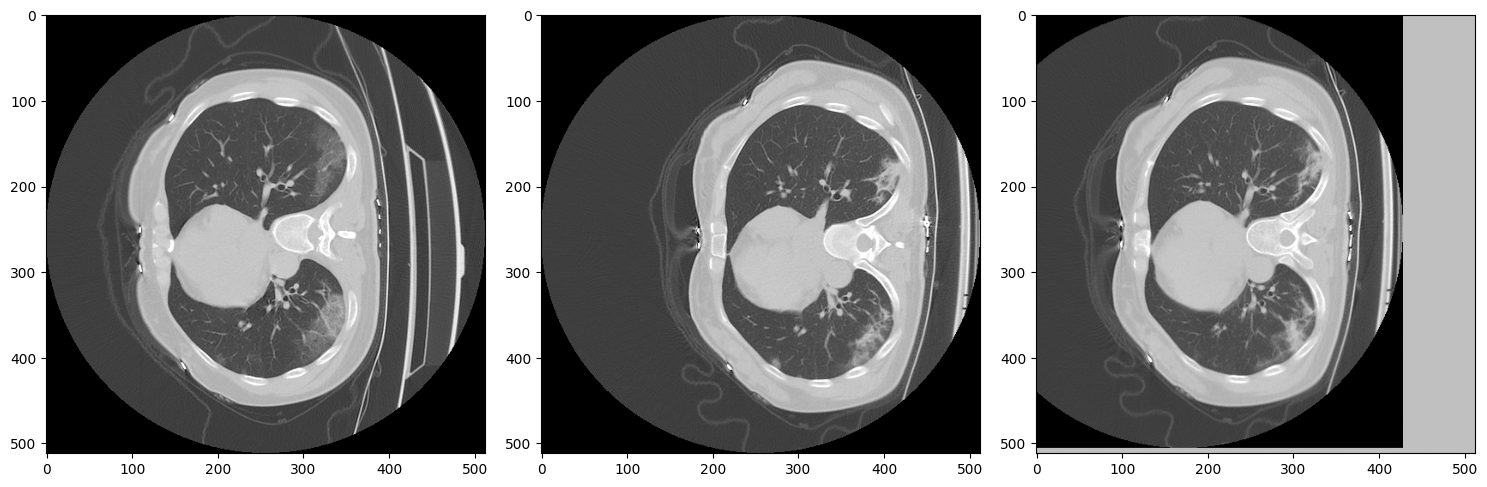

In [12]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(ct_base[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.subplot(132)
plt.imshow(ct_FU[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.subplot(133)
plt.imshow(ct_FU_reg[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.tight_layout()
plt.show()

Exercise 1. local histogram equalization을 통해 숨겨진 패턴 확인하기

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
imgpath = '/content/drive/MyDrive/DIP4E/DIP4E'
os.listdir(imgpath)

['test-pattern-gaussian-noise.tif',
 'Fig81c.tif',
 'WashingtonDC-Band4-NearInfrared-564.tif',
 'glass-caster-RGB.tif',
 'numbers.tif',
 'cktboard-controller.tif',
 'four-squares.tif',
 'testpattern8192.tif',
 'turbineblad-with-blk-dot.tif',
 'letterA-distorted.tif',
 'GT.tif',
 'Fig81b.tif',
 'galaxy-pair.tif',
 'polymercell.tif',
 'washingtonDC-Band6-ThermalInfrared-512.tif',
 'edge-roof.tif',
 'angiography-mask-image.tif',
 'lenna-RGB.tif',
 'strip-uniform-noise.tif',
 'RGB-color-cube.tif',
 'painting.tif',
 'wingding-circle-target.tif',
 'book-cover-gaussian.tif',
 'OpticalMicroscope-superconductor-smooth-texture.tif',
 'americas-at-night4.tif',
 'calculator-binary.tif',
 'wingding-star-3pt.tif',
 'matches-aligned.tif',
 'hurricane-katrina-eye.tif',
 'shepp-logan-phantom.tif',
 'cygnusloop.tif',
 'Fig81a.tif',
 'wingding-circle-solid.tif',
 'bonescan-back.tif',
 'dowels.tif',
 'phobos.tif',
 'wingding-square-solid.tif',
 'WashingtonDC-RGBfrom-Bands-4-2-1.tif',
 'blurry-moon.tif',
 

In [8]:
#histogram equalization 관련 코드
def histogram_equalization(image):
    histogram, bins = np.histogram(image.flatten(), bins=256, range=[0,256])
    cdf = histogram.cumsum()
    cdf_min = cdf.min()
    cdf_max = cdf.max()
    cdf_normalized = (cdf - cdf_min) * 255 / (cdf_max - cdf_min)
    cdf_normalized = cdf_normalized.astype(np.uint8)
    equalized_image = cdf_normalized[image]
    return equalized_image

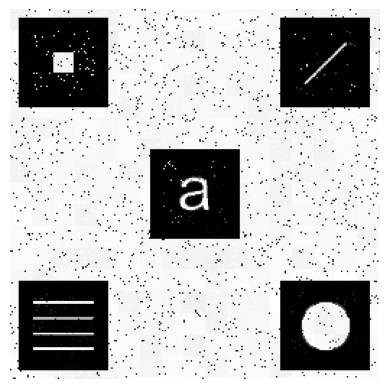

In [25]:
N = 15

f = plt.imread(imgpath+'/hidden-symbols.tif')
f_eq_local = np.zeros_like(f)
for x in np.arange(0,256,N):
  for y in np.arange(0,256,N):
    f_eq_local[x:x+N,y:y+N] = histogram_equalization(f[x:x+N,y:y+N])

plt.imshow(f_eq_local,vmin=0,vmax=255,cmap='gray')
plt.axis('off')
plt.show()

Exercise 2. 본인의 사진을 grayscale image로 불러온 후, 서로 다른 kernel size에 대한 LPF결과 비교

In [29]:
import time
import scipy.signal as signal
from skimage import io

In [41]:
#원본 이미지 10배 다운 샘플
f = io.imread('IMG_001.jpg',as_gray=True)[::10,::10]
print(f.shape,f.dtype)

(519, 346) float64


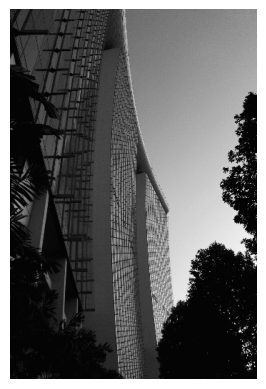

In [42]:
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.show()

computation time =  0.01793980598449707  sec


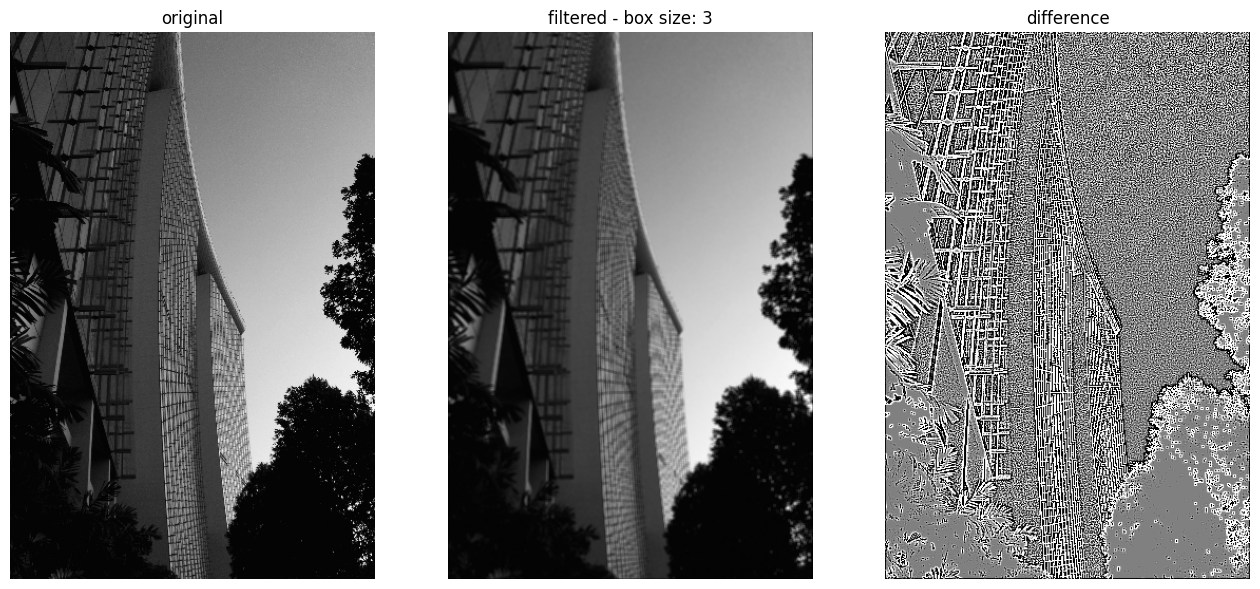

computation time =  0.07938623428344727  sec


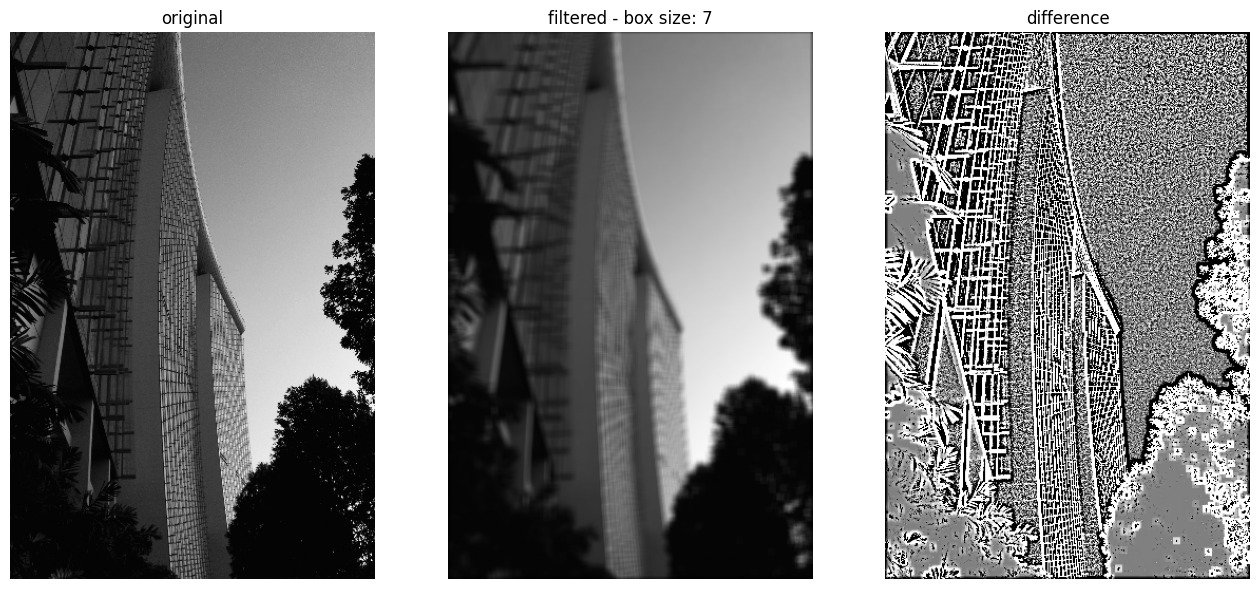

computation time =  0.20429444313049316  sec


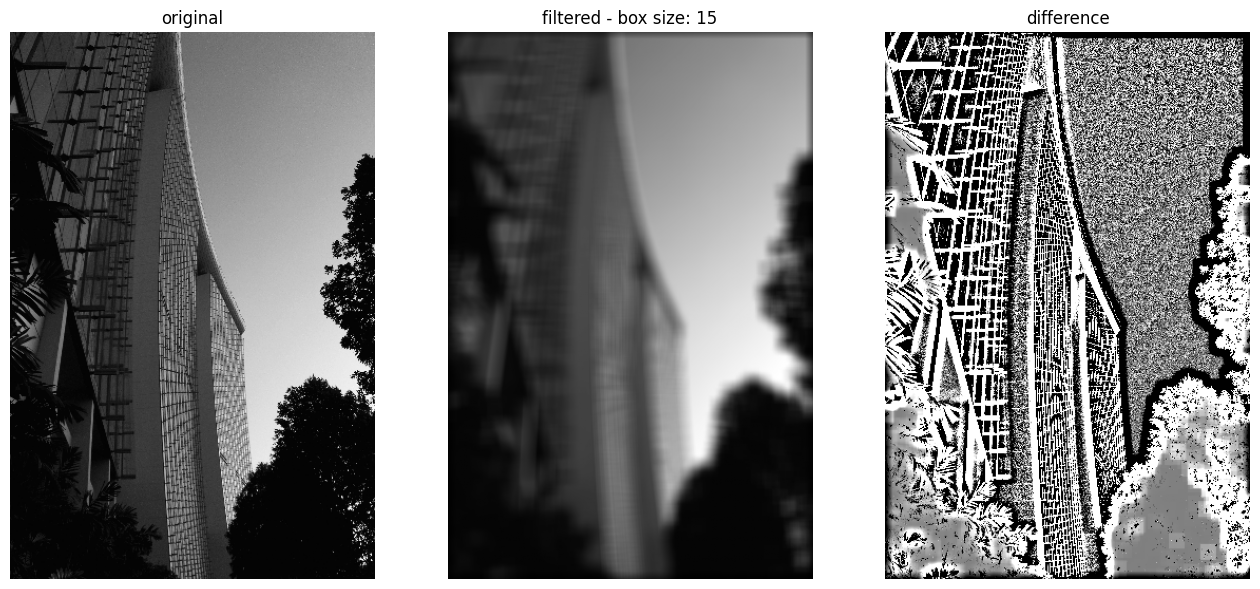

computation time =  0.7751591205596924  sec


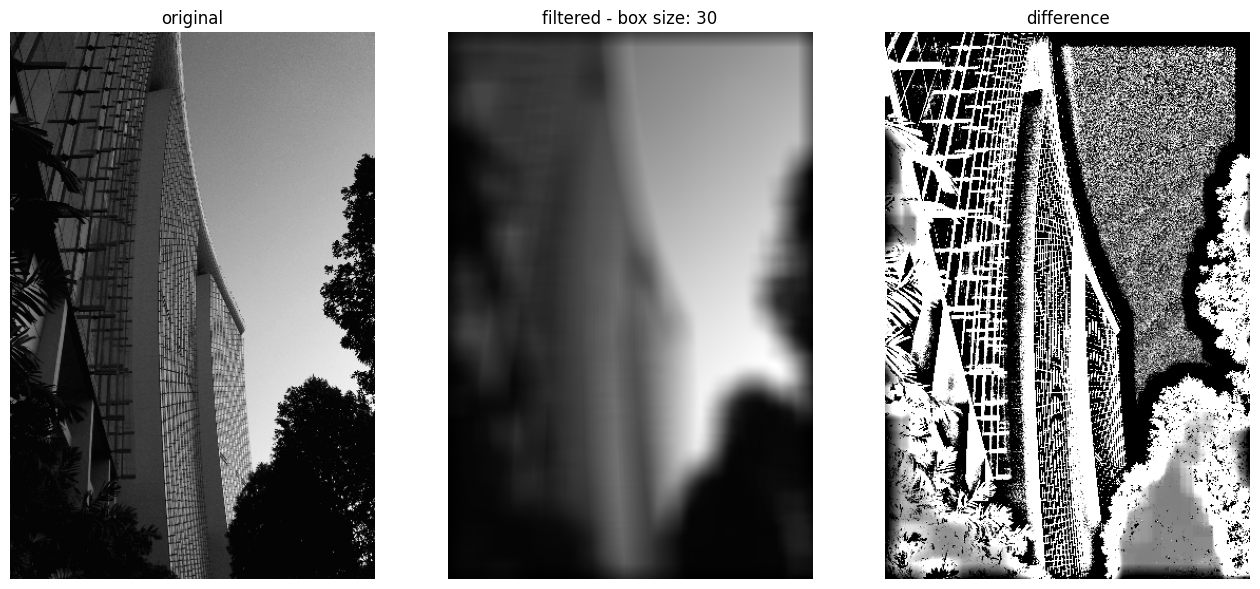

In [44]:
for N in np.array([3,7,15,30]):
  wb = np.ones((N,N))
  wb = wb/np.sum(wb)
  s0 = time.time()
  y_b = signal.convolve2d(f,wb,mode='same')
  compu_time=time.time() - s0
  print('computation time = ', compu_time,' sec')
  plt.figure(figsize=(16,9))
  plt.subplot(1,3,1)
  plt.imshow(f,cmap='gray')
  plt.axis('off')
  plt.title('original')
  plt.subplot(1,3,2)
  plt.imshow(y_b,cmap='gray')
  plt.axis('off')
  plt.title(f'filtered - box size: {N}')
  plt.subplot(1,3,3)
  plt.imshow(y_b-f,cmap='gray',vmin=-.01,vmax=.01)
  plt.axis('off')
  plt.title('difference')
  plt.show()

Exercise 3. Blurring이 발생한 사진을 가져와서 적당한 HPF결과를 활용하여 sharpening을 진행하기

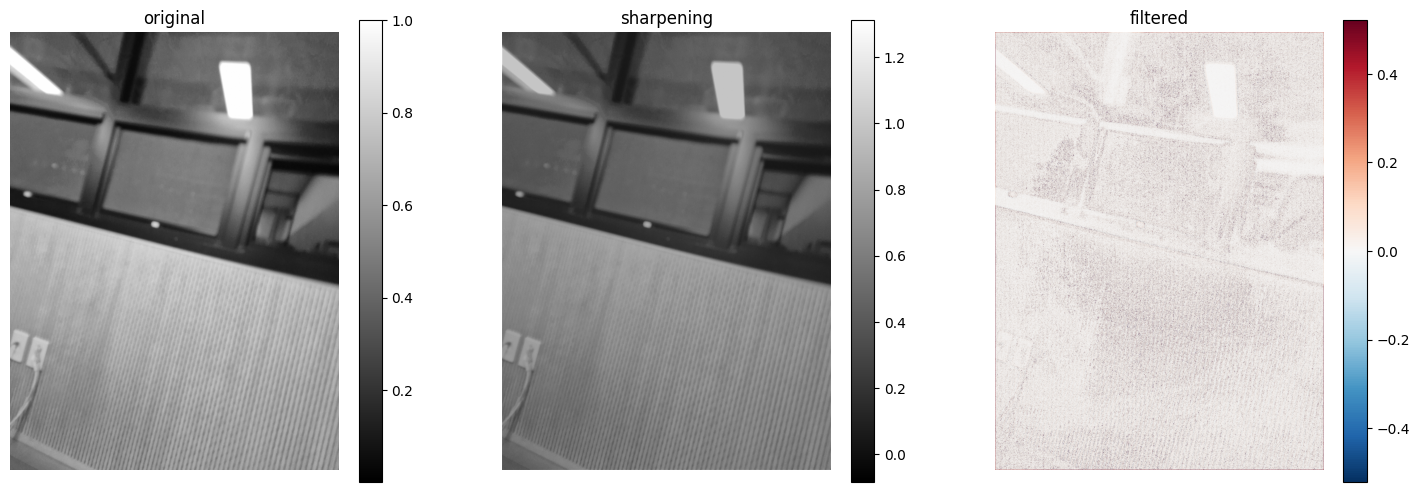

In [69]:
#f = plt.imread(os.path.join(imgpath,'IMG_002.jpg'))
f = io.imread('IMG_002.jpg',as_gray=True)[::2,::2]
f = np.rot90(f, k=-1)

w = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])
y = signal.convolve2d(f,w,mode='same')
c = 0.3
g = f + c*(y)
plt.figure(figsize=(18,6))
plt.subplot(131)
plt.imshow(f,cmap='gray')
plt.colorbar()
plt.axis('off')
plt.title('original')
plt.subplot(132)
plt.imshow(g,cmap='gray')
plt.colorbar()
plt.axis('off')
plt.title('sharpening')
plt.subplot(133)
plt.imshow(y,cmap='RdBu_r',vmin=-0.5*np.max(np.abs(y)),vmax=0.5*np.max(np.abs(y)))
plt.colorbar()
plt.axis('off')
plt.title('filtered')
plt.show()